In [1]:
# The project was supposed to use real-time analysis on amazoon reviews using amazon review scrapper. However, I am postpone the comments scrapping due to the new policies and limitations of Amazon. In this regard, the dataset from Kaggle website is used to proceed the project.

import pandas as pd
data = pd.read_csv("E:\Class\software\Reviews.csv")
data.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\V I S I O N\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\V I S I O N\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\V I S I O N\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\V I S I O N\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\V I S

AttributeError: _ARRAY_API not found

,No.,Name,Date,Likes,Comment,view source
0,1.0,phonearena,27/11/19 10:55:17,0.0,",All good but fingerprint sensor not working s...",NaN
1,2.0,geri_ingmar,27/11/19 13:37:16,0.0,Good phone. But there is some issue in display...,NaN
2,3.0,officialsitso,27/11/19 13:41:44,0.0,You did not mention one feature. Covid-19 the ...,NaN
3,13.0,just_tonee,27/11/19 14:08:37,0.0,Awesome phone in this price and this is my sec...,NaN
4,14.0,kurtxmichael,27/11/19 14:09:50,0.0,The best of specifications with worst of funct...,NaN


In [2]:
columns = ['No.', 'Name', 'Date', 'Likes', 'view source']
data.drop(columns, inplace=True, axis=1)

In [3]:
data.head()


,Comment
0,",All good but fingerprint sensor not working s..."
1,Good phone. But there is some issue in display...
2,You did not mention one feature. Covid-19 the ...
3,Awesome phone in this price and this is my sec...
4,The best of specifications with worst of funct...


In [4]:
import re

def cleancomments(comment):
    comment = re.sub('@[A-Za-z0-9_]+','',str(comment))
    comment = re.sub('https://[A-Za-z0-9./]+','',str(comment))
    comment = re.sub('#[A-Za-z0-9./]+','',str(comment))
    comment = re.sub(r'[^\w]', ' ', str(comment))
    comment = comment.lower()
    return comment


In [5]:
for index, row in data.iterrows():
    data.loc[index,'Cleancomment'] = cleancomments(data.loc[index,'Comment'])

data

,Comment,Cleancomment
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...
...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...
25413,",Awesome Gaget.. @ this price",awesome gaget this price
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...


In [6]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('english'))



[nltk_data] Downloading package stopwords to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
data['applied stop_words'] = data['Cleancomment'].apply(lambda x: ' '.join([comment for comment in x.split() if comment not in (stop_words)]))
data

,Comment,Cleancomment,applied stop_words
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...,good fingerprint sensor working sometime
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...,good phone issue displaying colors screen
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...,mention one feature covid 19 smart infected fe...
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...,awesome phone price second mobile s8 fast disp...
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...,best specifications worst functions worst phon...
...,...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...,really like phone everything working fine what...
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...,s8 k8 note awesome takes best pictures dual ca...
25413,",Awesome Gaget.. @ this price",awesome gaget this price,awesome gaget price
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...,phone nice processing successful dual camera s...


In [8]:
import nltk
from nltk.tokenize import word_tokenize
data['tokenized_Comments'] = data.apply(lambda row: nltk.word_tokenize(row['applied stop_words']), axis=1)

In [9]:
data

,Comment,Cleancomment,applied stop_words,tokenized_Comments
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...,good fingerprint sensor working sometime,"[good, fingerprint, sensor, working, sometime]"
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...,good phone issue displaying colors screen,"[good, phone, issue, displaying, colors, screen]"
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...,mention one feature covid 19 smart infected fe...,"[mention, one, feature, covid, 19, smart, infe..."
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...,awesome phone price second mobile s8 fast disp...,"[awesome, phone, price, second, mobile, s8, fa..."
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...,best specifications worst functions worst phon...,"[best, specifications, worst, functions, worst..."
...,...,...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...,really like phone everything working fine what...,"[really, like, phone, everything, working, fin..."
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...,s8 k8 note awesome takes best pictures dual ca...,"[s8, k8, note, awesome, takes, best, pictures,..."
25413,",Awesome Gaget.. @ this price",awesome gaget this price,awesome gaget price,"[awesome, gaget, price]"
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...,phone nice processing successful dual camera s...,"[phone, nice, processing, successful, dual, ca..."


In [10]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('punkt')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

data['lemmatized_Comments'] = data['tokenized_Comments'].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

[nltk_data] Downloading package punkt to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
data

,Comment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...,good fingerprint sensor working sometime,"[good, fingerprint, sensor, working, sometime]","[good, fingerprint, sensor, working, sometime]"
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...,good phone issue displaying colors screen,"[good, phone, issue, displaying, colors, screen]","[good, phone, issue, displaying, color, screen]"
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...,mention one feature covid 19 smart infected fe...,"[mention, one, feature, covid, 19, smart, infe...","[mention, one, feature, covid, 19, smart, infe..."
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...,awesome phone price second mobile s8 fast disp...,"[awesome, phone, price, second, mobile, s8, fa...","[awesome, phone, price, second, mobile, s8, fa..."
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...,best specifications worst functions worst phon...,"[best, specifications, worst, functions, worst...","[best, specification, worst, function, worst, ..."
...,...,...,...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...,really like phone everything working fine what...,"[really, like, phone, everything, working, fin...","[really, like, phone, everything, working, fin..."
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...,s8 k8 note awesome takes best pictures dual ca...,"[s8, k8, note, awesome, takes, best, pictures,...","[s8, k8, note, awesome, take, best, picture, d..."
25413,",Awesome Gaget.. @ this price",awesome gaget this price,awesome gaget price,"[awesome, gaget, price]","[awesome, gaget, price]"
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...,phone nice processing successful dual camera s...,"[phone, nice, processing, successful, dual, ca...","[phone, nice, processing, successful, dual, ca..."


In [12]:
#https://github.com/clieb3/pos-tagger-comparison/blob/master/tagger-comparison.ipynb
#paper: Tagging Efficiency Analysis on Part of Speech Taggers

from nltk.tag.perceptron import PerceptronTagger

nltk.download('averaged_perceptron_tagger')

tagger = PerceptronTagger()

data['pos_tags'] = data['lemmatized_Comments'].apply (lambda tokens: tagger.tag(tokens))

data

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\V I S I O N\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,Comment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments,pos_tags
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...,good fingerprint sensor working sometime,"[good, fingerprint, sensor, working, sometime]","[good, fingerprint, sensor, working, sometime]","[(good, JJ), (fingerprint, NN), (sensor, NN), ..."
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...,good phone issue displaying colors screen,"[good, phone, issue, displaying, colors, screen]","[good, phone, issue, displaying, color, screen]","[(good, JJ), (phone, NN), (issue, NN), (displa..."
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...,mention one feature covid 19 smart infected fe...,"[mention, one, feature, covid, 19, smart, infe...","[mention, one, feature, covid, 19, smart, infe...","[(mention, NN), (one, CD), (feature, NN), (cov..."
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...,awesome phone price second mobile s8 fast disp...,"[awesome, phone, price, second, mobile, s8, fa...","[awesome, phone, price, second, mobile, s8, fa...","[(awesome, JJ), (phone, NN), (price, NN), (sec..."
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...,best specifications worst functions worst phon...,"[best, specifications, worst, functions, worst...","[best, specification, worst, function, worst, ...","[(best, JJS), (specification, NN), (worst, JJS..."
...,...,...,...,...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...,really like phone everything working fine what...,"[really, like, phone, everything, working, fin...","[really, like, phone, everything, working, fin...","[(really, RB), (like, IN), (phone, NN), (every..."
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...,s8 k8 note awesome takes best pictures dual ca...,"[s8, k8, note, awesome, takes, best, pictures,...","[s8, k8, note, awesome, take, best, picture, d...","[(s8, JJ), (k8, NN), (note, NN), (awesome, JJ)..."
25413,",Awesome Gaget.. @ this price",awesome gaget this price,awesome gaget price,"[awesome, gaget, price]","[awesome, gaget, price]","[(awesome, JJ), (gaget, NN), (price, NN)]"
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...,phone nice processing successful dual camera s...,"[phone, nice, processing, successful, dual, ca...","[phone, nice, processing, successful, dual, ca...","[(phone, NN), (nice, JJ), (processing, NN), (s..."


In [13]:
def extract_nouns(pos_tags):
    if not isinstance(pos_tags, list):
        return []
    return [word for word, tag in pos_tags if tag.startswith('NN')]


In [14]:
data['nouns'] = data['pos_tags'].apply(extract_nouns)
data


,Comment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments,pos_tags,nouns
0,",All good but fingerprint sensor not working s...",all good but fingerprint sensor not working s...,good fingerprint sensor working sometime,"[good, fingerprint, sensor, working, sometime]","[good, fingerprint, sensor, working, sometime]","[(good, JJ), (fingerprint, NN), (sensor, NN), ...","[fingerprint, sensor]"
1,Good phone. But there is some issue in display...,good phone but there is some issue in display...,good phone issue displaying colors screen,"[good, phone, issue, displaying, colors, screen]","[good, phone, issue, displaying, color, screen]","[(good, JJ), (phone, NN), (issue, NN), (displa...","[phone, issue, color, screen]"
2,You did not mention one feature. Covid-19 the ...,you did not mention one feature covid 19 the ...,mention one feature covid 19 smart infected fe...,"[mention, one, feature, covid, 19, smart, infe...","[mention, one, feature, covid, 19, smart, infe...","[(mention, NN), (one, CD), (feature, NN), (cov...","[mention, feature, smart, feature, s8, phone, ..."
3,Awesome phone in this price and this is my sec...,awesome phone in this price and this is my sec...,awesome phone price second mobile s8 fast disp...,"[awesome, phone, price, second, mobile, s8, fa...","[awesome, phone, price, second, mobile, s8, fa...","[(awesome, JJ), (phone, NN), (price, NN), (sec...","[phone, price, s8, display]"
4,The best of specifications with worst of funct...,the best of specifications with worst of funct...,best specifications worst functions worst phon...,"[best, specifications, worst, functions, worst...","[best, specification, worst, function, worst, ...","[(best, JJS), (specification, NN), (worst, JJS...","[specification, function, phone]"
...,...,...,...,...,...,...,...
25411,",""I really like the phone, Everything is worki...",i really like the phone everything is worki...,really like phone everything working fine what...,"[really, like, phone, everything, working, fin...","[really, like, phone, everything, working, fin...","[(really, RB), (like, IN), (phone, NN), (every...","[phone, everything, whater, use, phone]"
25412,",""The s8 K8 Note is awesome. It takes best pic...",the s8 k8 note is awesome it takes best pic...,s8 k8 note awesome takes best pictures dual ca...,"[s8, k8, note, awesome, takes, best, pictures,...","[s8, k8, note, awesome, take, best, picture, d...","[(s8, JJ), (k8, NN), (note, NN), (awesome, JJ)...","[k8, note, take, picture, camera, body, bit, h..."
25413,",Awesome Gaget.. @ this price",awesome gaget this price,awesome gaget price,"[awesome, gaget, price]","[awesome, gaget, price]","[(awesome, JJ), (gaget, NN), (price, NN)]","[gaget, price]"
25414,",This phone is nice processing will be success...",this phone is nice processing will be success...,phone nice processing successful dual camera s...,"[phone, nice, processing, successful, dual, ca...","[phone, nice, processing, successful, dual, ca...","[(phone, NN), (nice, JJ), (processing, NN), (s...","[phone, processing, camera, mod]"


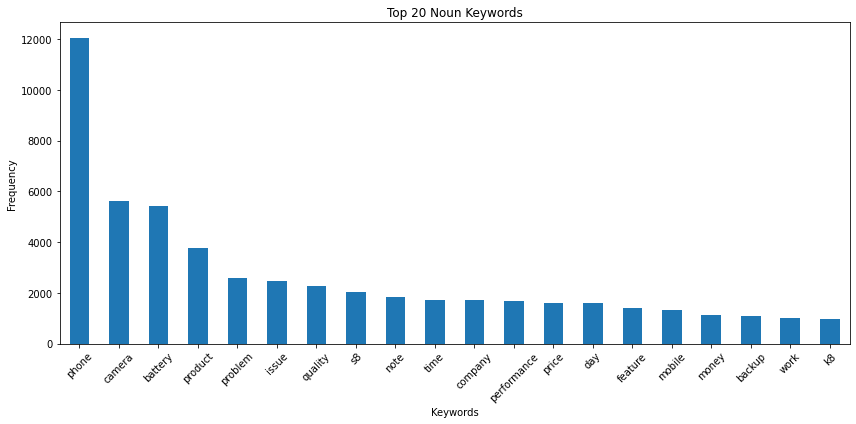

In [15]:
import matplotlib.pyplot as plt

noun_counts = data['nouns'].explode().value_counts().head(20)
plt.figure(figsize=(12,6))
noun_counts.plot(kind='bar')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.title('Top 20 Noun Keywords')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
useless_aspects = [
    'phone','product','mobile','device','amazon',
    'item','company','cell','smartphone'
]

noun_counts = (
    data['nouns']
    .explode()
    .loc[lambda x: ~x.isin(useless_aspects)]
    .value_counts()
    .head(20)
)


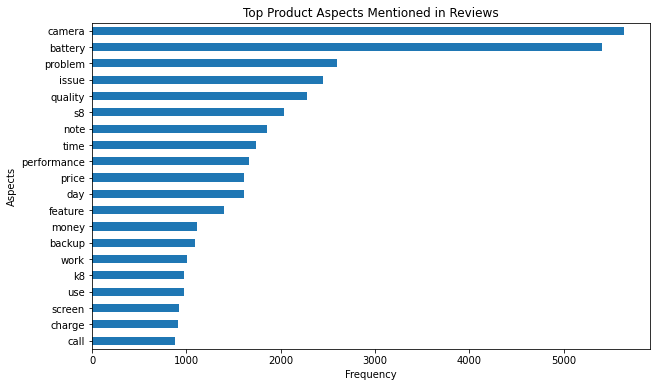

In [17]:
plt.figure(figsize=(10,6))
noun_counts.sort_values().plot(kind='barh')
plt.title('Top Product Aspects Mentioned in Reviews')
plt.xlabel('Frequency')
plt.ylabel('Aspects')

plt.show()

In [18]:
import nltk
def get_all_phrases_containing_tar_wrd(target_word, tar_passage, left_margin = 5, right_margin = 5):
    tokens = nltk.word_tokenize(tar_passage)
    tokens = [x for x in tokens if len(x)>2] 
    text = nltk.Text(tokens)
    c = nltk.ConcordanceIndex(text.tokens, key = lambda s: s.lower())
    concordance_txt = ([text.tokens[  list(map(lambda x: x-5 if (x-left_margin)>0 else 0,[offset]))[0]:offset+right_margin] for offset in c.offsets(target_word)])
    return [''.join([x+' ' for x in con_sub]) for con_sub in concordance_txt]